# Variable Diagnostics for Probability of Default (PD) Modelling

This notebook performs exploratory analysis and diagnostics on the cleaned LendingClub loan dataset prepared in the previous stage.

The goal of this stage is to understand the statistical properties and predictive behaviour of the variables before building the PD model.

Proper variable diagnostics help identify:

- variables with extreme distributions
- potential outliers
- skewness and heavy tails
- variables that may have predictive power for default

This step is essential in credit risk modelling because poorly behaved variables can lead to unstable models and unreliable probability of default estimates.

---

## Data Source

The dataset used in this notebook is the cleaned dataset generated in the previous stage:

`01_data_preparation.ipynb`

File used:

`loan_data_cleaned.csv`

---

## Diagnostics Performed in This Notebook

The following analyses will be conducted:

1. Load and inspect the cleaned dataset
2. Examine variable types (numeric vs categorical)
3. Summary statistics of numeric variables
4. Distribution analysis
5. Skewness and kurtosis analysis
6. Event rate analysis with respect to default

These diagnostics help guide the next stage of the modelling pipeline: **variable binning and Information Value (IV) analysis**.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%pwd

'C:\\Users\\amit_\\Github\\credit-portfolio-vasicek-simulation\\notebooks'

In [3]:
loan_data = pd.read_csv("../data/processed/loan_data_cleaned.csv")

In [4]:
loan_data.shape

(230795, 50)

In [5]:
loan_data.head(5)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,home_ownership,annual_inc,...,issue_date,months_since_issue_date,mths_since_last_delinq_missing,annual_inc_missing,emp_length_missing,mths_since_last_record_missing,mths_since_last_major_derog_missing,tot_cur_bal_missing,total_rev_hi_lim_missing,tot_coll_amt_missing
0,5000,5000,4975.0,36 months,10.65,162.87,B,B2,RENT,24000.0,...,2011-12-01,169,1,0,0,1,1,1,1,1
1,2500,2500,2500.0,60 months,15.27,59.83,C,C4,RENT,30000.0,...,2011-12-01,169,1,0,0,1,1,1,1,1
2,2400,2400,2400.0,36 months,15.96,84.33,C,C5,RENT,18000.0,...,2011-12-01,169,1,0,0,1,1,1,1,1
3,10000,10000,10000.0,36 months,13.49,339.31,C,C1,RENT,49200.0,...,2011-12-01,169,0,0,0,1,1,1,1,1
4,5000,5000,5000.0,36 months,7.90,156.46,A,A4,RENT,36000.0,...,2011-12-01,169,1,0,0,1,1,1,1,1


## Summary Statistics of Numeric Variables

The table above shows the descriptive statistics for all numeric variables in the dataset.

Key statistics included are:

- **Mean** – average value of the variable
- **Standard deviation** – variability of the variable
- **Minimum / Maximum** – extreme values
- **Quartiles (25%, 50%, 75%)** – distribution spread

These statistics help identify:

- potential **outliers**
- variables with **very large ranges**
- variables with **unusual values**

Understanding the basic distribution of variables is an important first step before building a credit risk model.

In [6]:
loan_data.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,230795.0,13412.187114,8042.975786,500.00,7200.00,12000.00,18000.00,35000.00
funded_amnt,230795.0,13365.295500,8017.161601,500.00,7200.00,12000.00,18000.00,35000.00
funded_amnt_inv,230795.0,13232.910101,8055.476489,0.00,7000.00,11750.00,18000.00,35000.00
int_rate,230795.0,13.781770,4.368738,5.42,10.74,13.65,16.40,26.06
installment,230795.0,414.692100,241.379651,51.26,237.19,363.85,543.44,1192.64
annual_inc,230795.0,70796.152850,38481.780879,18000.00,45000.00,61920.00,86000.00,235000.00
dti,230795.0,16.348890,7.672534,0.00,10.64,16.05,21.77,39.99
delinq_2yrs,230795.0,0.243272,0.724468,0.00,0.00,0.00,0.00,29.00
inq_last_6mths,230795.0,0.907554,1.175969,0.00,0.00,1.00,1.00,33.00
mths_since_last_delinq,230795.0,576.678884,478.504308,0.00,37.00,999.00,999.00,999.00


## Skewness and Kurtosis Analysis

To further understand the distribution of variables, skewness and kurtosis are calculated.

### Skewness
Skewness measures the asymmetry of a distribution.

- **Skew ≈ 0** → symmetric distribution
- **Positive skew (>0)** → long right tail
- **Negative skew (<0)** → long left tail

Financial variables such as income, loan balances, and credit utilisation are often **right-skewed**, meaning a small number of observations have very large values.

### Kurtosis
Kurtosis measures the heaviness of the tails of a distribution.

- **High kurtosis** → presence of extreme outliers
- **Low kurtosis** → lighter tails

Understanding skewness and kurtosis helps detect variables that may require **binning or transformation** before modelling.

In [7]:
loan_data.select_dtypes(include ='number').agg(['skew','kurtosis']).T

,skew,kurtosis
loan_amnt,0.846063,0.153761
funded_amnt,0.853800,0.179334
funded_amnt_inv,0.847454,0.182164
int_rate,0.326653,-0.291421
installment,0.968246,0.732880
annual_inc,1.667919,3.752133
dti,0.182454,-0.531413
delinq_2yrs,5.807827,66.519218
inq_last_6mths,2.343024,18.478374
mths_since_last_delinq,-0.252265,-1.932751


In [8]:
loan_data['policy_code'].value_counts()

policy_code
1    230795
Name: count, dtype: int64

### Constant Variable Removal

The variable `policy_code` was examined and found to contain only a single value across all observations.

Since the variable has **zero variance**, it does not provide any predictive information for the model.

Such variables cannot contribute to explaining default risk and are therefore removed from the dataset.

In [9]:
loan_data = loan_data.drop(columns=['policy_code'])

## *Grade vs Default Rate*

In [10]:
grade_event_rate = loan_data.groupby('grade')['default'].mean()

grade_event_rate

grade
A    0.065584
B    0.132976
C    0.210265
D    0.276456
E    0.353969
F    0.408208
G    0.439116
Name: default, dtype: float64

In [11]:
loan_data.groupby('grade')['default'].agg(['count','mean'])

,count,mean
grade,,
A,39110,0.065584
B,70622,0.132976
C,58626,0.210265
D,36740,0.276456
E,16945,0.353969
F,6896,0.408208
G,1856,0.439116


### Interpretation of Default Rate by Grade

The LendingClub grade variable shows a strong monotonic relationship with default risk.

Default rates increase steadily from Grade A to Grade G:

A → 6.5%  
B → 13.3%  
C → 21.0%  
D → 27.6%  
E → 35.4%  
F → 40.8%  
G → 43.9%

This behaviour confirms that the grade variable effectively captures borrower credit risk. Variables that exhibit a clear monotonic relationship with default probability are strong candidates for inclusion in a credit risk model.

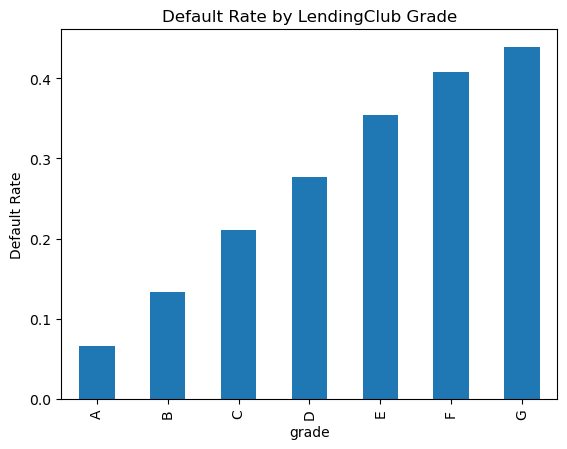

In [12]:
grade_event_rate.plot(kind='bar')

plt.ylabel("Default Rate")
plt.title("Default Rate by LendingClub Grade")

plt.show()

### Default Rate by LendingClub Grade

The variable **grade** represents LendingClub's internal credit rating of the borrower.

Grades range from **A (lowest risk)** to **G (highest risk)**.

By examining the default rate across grades, we can assess whether the variable effectively captures credit risk.

A well-behaved credit risk variable should show a **monotonic relationship**, meaning default rates increase as credit quality decreases.

### Default Rate by Sub-Grade

The variable **sub_grade** provides a more granular classification of borrower credit risk compared to the grade variable.

Each grade (A–G) is divided into five sub-categories (e.g., A1–A5, B1–B5).

Analyzing default rates across sub-grades allows us to verify whether default probability increases consistently as credit quality deteriorates.

In [13]:
subgrade_event_rate = loan_data.groupby('sub_grade')['default'].mean()

subgrade_event_rate

sub_grade
A1    0.032895
A2    0.048077
A3    0.058665
A4    0.073977
A5    0.087450
B1    0.107216
B2    0.115506
B3    0.130940
B4    0.146523
B5    0.159736
C1    0.177499
C2    0.190919
C3    0.220201
C4    0.232506
C5    0.244407
D1    0.254089
D2    0.267302
D3    0.270609
D4    0.300749
D5    0.305454
E1    0.325502
E2    0.352782
E3    0.346108
E4    0.375423
E5    0.387535
F1    0.374555
F2    0.384468
F3    0.423944
F4    0.440037
F5    0.462617
G1    0.464115
G2    0.425110
G3    0.460526
G4    0.377049
G5    0.436123
Name: default, dtype: float64

In [14]:
loan_data.groupby('sub_grade')['default'].agg(['count','mean'])

,count,mean
sub_grade,,
A1,5472,0.032895
A2,5720,0.048077
A3,6699,0.058665
A4,10287,0.073977
A5,10932,0.087450
B1,11211,0.107216
B2,13627,0.115506
B3,17046,0.130940
B4,15704,0.146523


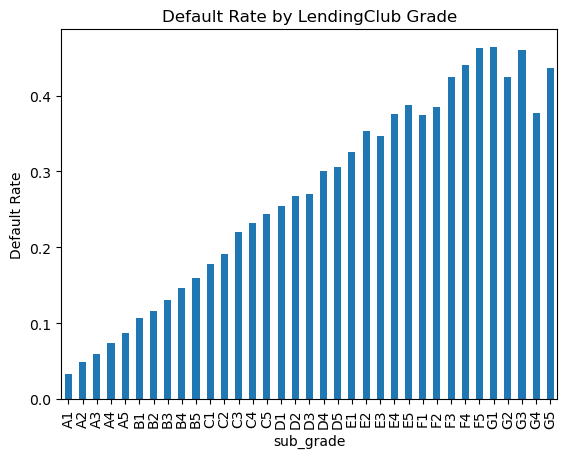

In [15]:
subgrade_event_rate.plot(kind='bar')

plt.ylabel("Default Rate")
plt.title("Default Rate by LendingClub Grade")

plt.show()

### Interpretation of Default Rate by Sub-Grade

The **sub_grade** variable provides a finer classification of borrower credit quality within each LendingClub grade.

Each grade (A–G) is divided into five sub-grades (e.g., A1–A5, B1–B5, etc.), representing increasing levels of credit risk.

From the results above, we observe the following pattern:

- Default rates increase consistently from **A1 → A5**, **B1 → B5**, and so on.
- The overall trend shows a clear increase in default probability as credit quality deteriorates.

For example:

| Sub Grade | Default Rate |
|-----------|--------------|
A1 | ~3.3% |
B1 | ~10.7% |
C1 | ~17.7% |
D1 | ~25.5% |
E1 | ~32.6% |
F1 | ~37.5% |
G1 | ~46.4% |

This demonstrates a strong **monotonic relationship** between sub-grade and default probability.

Variables that show a clear monotonic relationship with the target variable are strong candidates for predictive modelling because they capture underlying credit risk effectively.

### Handling Multicollinearity: Grade vs Sub-Grade

The variables **grade** and **sub_grade** both represent LendingClub’s internal assessment of borrower credit risk.

However, **sub_grade is a more granular version of grade**. Each grade (A–G) is subdivided into five categories:

A1–A5  
B1–B5  
C1–C5  
D1–D5  
E1–E5  
F1–F5  
G1–G5  

Because of this relationship, the information contained in **grade is completely determined by sub_grade**. In statistical terms, these variables are **highly collinear**.

#### Why this matters for modelling

In regression models, highly collinear predictors can cause **multicollinearity**, which leads to:

- unstable coefficient estimates  
- inflated standard errors  
- unreliable p-values  
- difficulty interpreting model coefficients  

From a linear algebra perspective, multicollinearity causes the design matrix **X** to lose full rank. When this happens, the matrix \(X^T X\) may become **singular or nearly singular**, meaning its inverse may not exist or may be numerically unstable.

Since regression estimation relies on the inversion of this matrix, multicollinearity can lead to **unstable model estimates**.
Multicollinearity occurs when one predictor variable can be expressed as a linear combination of another predictor. In this case, the information contained in **grade** is already fully captured by **sub_grade**, which makes the design matrix nearly rank deficient if both variables are included.

#### Resolution

To avoid this issue, we retain the more informative variable **sub_grade** and remove **grade** from the dataset.

In [16]:
loan_data = loan_data.drop(columns=['grade'])

In [17]:
loan_data.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'sub_grade', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'pymnt_plan',
       'purpose', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs',
       'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'collections_12_mths_ex_med',
       'mths_since_last_major_derog', 'application_type', 'acc_now_delinq',
       'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'default',
       'term_month', 'emp_length_years', 'months_since_earliest_cr_line',
       'issue_date', 'months_since_issue_date',
       'mths_since_last_delinq_missing', 'annual_inc_missing',
       'emp_length_missing', 'mths_since_last_record_missing',
       'mths_since_last_major_derog_missing', 'tot_cur_bal_missing',
       'total_rev_hi_lim_missing', 'tot_coll_amt_missi

### Interpretation of Default Rate by Interest Rate

In [18]:
loan_data['int_rate_bin'] = pd.qcut(loan_data['int_rate'],q=10)

In [22]:
int_rate_event_rate = loan_data.groupby('int_rate_bin', observed = True)['default'].mean()
int_rate_event_rate

int_rate_bin
(5.419, 7.9]      0.057240
(7.9, 9.91]       0.095820
(9.91, 11.14]     0.116281
(11.14, 12.49]    0.142192
(12.49, 13.65]    0.166534
(13.65, 14.49]    0.187784
(14.49, 15.8]     0.222043
(15.8, 17.57]     0.265223
(17.57, 19.52]    0.296392
(19.52, 26.06]    0.383065
Name: default, dtype: float64

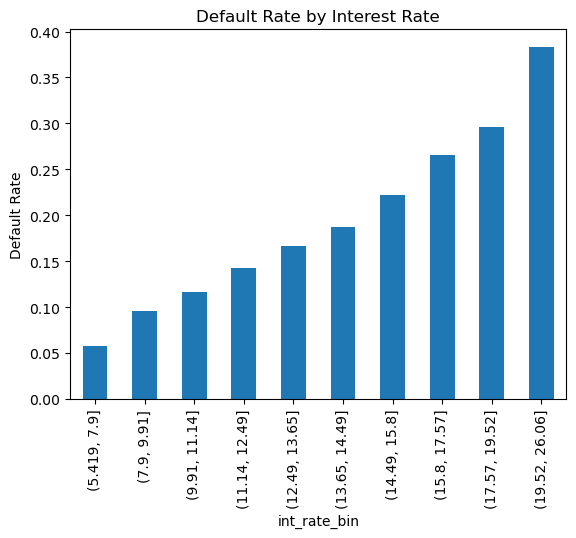

In [23]:
int_rate_event_rate.plot(kind = 'bar')
plt.ylabel("Default Rate")
plt.title("Default Rate by Interest Rate")

plt.show()

### Interpretation of Default Rate by Interest Rate

Interest rate shows a clear monotonic relationship with default probability.

As the interest rate increases, the observed default rate also increases steadily across bins. This behaviour is economically intuitive because higher interest rates are typically assigned to borrowers with higher perceived credit risk.

Variables that display a stable monotonic relationship with default probability are strong candidates for predictive modelling and are well suited for later WoE binning.

### Default Rate by Debt to Income ratio (DTI)

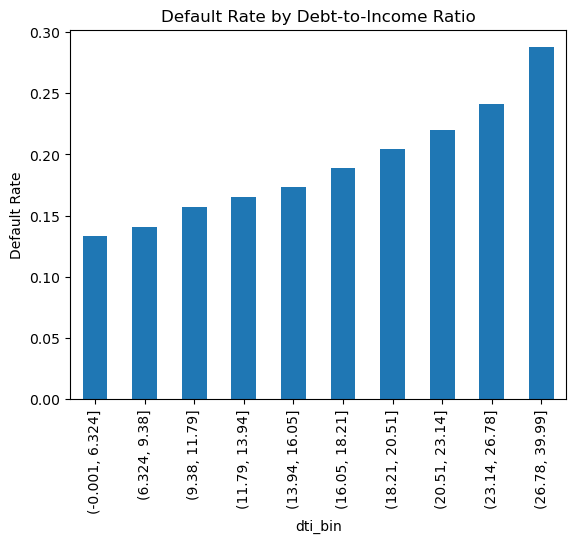

In [25]:
loan_data['dti_bin'] = pd.qcut(loan_data['dti'], q=10)

dti_event = loan_data.groupby('dti_bin', observed = True)['default'].mean()

dti_event.plot(kind='bar')

plt.ylabel("Default Rate")
plt.title("Default Rate by Debt-to-Income Ratio")

plt.show()

### Interpretation 
Above variable display a stable monotonic relationship with default probability are strong candidates for predictive modelling and are well suited for later WoE binning.

### Default Rate by Debt to Revolving Utilization

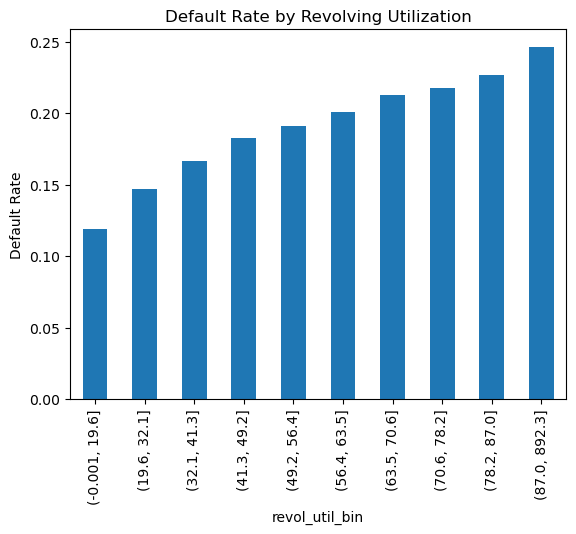

In [29]:
loan_data['revol_util_bin'] = pd.qcut(loan_data['revol_util'], q=10)

revol_util_event = loan_data.groupby('revol_util_bin', observed = True)['default'].mean()

revol_util_event.plot(kind='bar')

plt.ylabel("Default Rate")
plt.title("Default Rate by Revolving Utilization")

plt.show()

### Interpretation 
Above variable display a stable monotonic relationship with default probability are strong candidates for predictive modelling and are well suited for later WoE binning.

### Default Rate by Annual Income

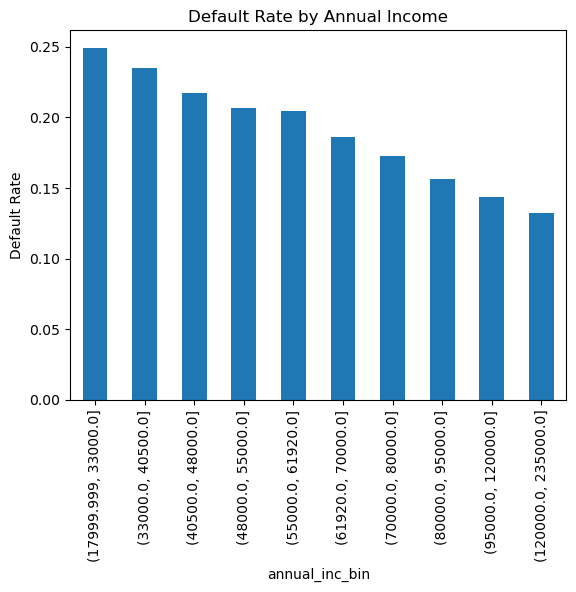

In [30]:
loan_data['annual_inc_bin'] = pd.qcut(loan_data['annual_inc'], q=10)

inc_event = loan_data.groupby('annual_inc_bin', observed=True)['default'].mean()

inc_event.plot(kind='bar')

plt.ylabel("Default Rate")
plt.title("Default Rate by Annual Income")

plt.show()

### Variable Diagnostics Scope

The dataset contains a large number of variables.  
For clarity and interpretability, detailed event-rate analysis is performed on key predictors that are economically relevant for credit risk modelling.

These include:

- LendingClub credit grade variables
- Interest rate
- Debt-to-income ratio
- Revolving credit utilization
- Borrower income

Other variables will be evaluated later using **Weight of Evidence (WoE)** and **Information Value (IV)** screening during the scorecard modelling stage.

## Variables Removed for Modelling

The following variables were removed based on diagnostics:

- policy_code → constant variable
- grade → multicollinearity with sub_grade